# Exploring EW4 data - GPM IMERG
This notebook explore the GPM IMERG dataset, including loading in PyEarthTools.

This dataset is a subset of the [NASA Integrated Multi-satellite Retrieval (IMERG)](https://gpm.nasa.gov/data/imerg) data for Global Precipitation Measurement (GPM). This subset has the following extents:
- Temporal Extent: April to September 2025
- Spatial Extent
  - Latitude 0N to 20N
  - Longitude 27W to 20E


### Import libraries

In [45]:
import pathlib
import datetime
import functools

In [114]:
import numpy

In [2]:
import xarray

In [3]:
import matplotlib
import cartopy.crs

In [4]:
import site_archive_jasmin

ROOT_DIRECTORIES: {'ERA5lowres': '/gws/nopw/j04/mohc_shared/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/gws/nopw/j04/mohc_shared//dscop/mo_pet_site_archive/mo_global/', 'MOUKV': '/gws/nopw/j04/mohc_shared//dscop/mo_pet_site_archive/mo_ukv/', 'Himawari': '/gws/ssde/j25a/mmh_storage/theme3/rv74_himawari', 'HimawariChannels': '/gws/ssde/j25a/mmh_storage/theme3/ra22_himawari', 'Rainfields3': '/gws/ssde/j25a/mmh_storage/theme3/rq0Radar', 'ew4_imerg_precip': '/gws/nopw/j04/ew4energy/imerg_2025_summer', 'ew4_merra2_meteo': '/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_meteo', 'ew4_merra2_aero': '/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_aerosols/3d', 'ew4_mtg_li': '/gws/nopw/j04/ew4energy/MTG_LI/', 'ew4_era5': '/gws/nopw/j04/ew4energy/ERA5/hourly/pl_levels'}


In [5]:
import pyearthtools

In [6]:
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe

In [7]:
from pyearthtools.data import Petdt, TimeDelta
from pyearthtools.data.exceptions import DataNotFoundError
from pyearthtools.data.indexes import ArchiveIndex, decorators
from pyearthtools.data.transforms import Transform, TransformCollection
from pyearthtools.data.archive import register_archive


In [8]:
from site_archive_jasmin.utilities import (
    cached_exists,
    cached_iterdir,
)  # Could these be moved into a generic module?


In [93]:
import torch

## Explore the data in the dataset
Lets start by looking at a sample data file, before demonstrating loading the data in pyearthtools

In [9]:
ew4_gws_dir = pathlib.Path('/gws/nopw/j04/ew4energy/')
imerg_ew4_dir = ew4_gws_dir / 'imerg_2025_summer'


In [10]:
def get_imerg_path(start_dt, time_delta, fname_template, data_dir):
    day_minutes = start_dt.hour * 60 + start_dt.minute
    date_str = '{dt.year:04d}{dt.month:02d}{dt.day:02d}'.format(dt=start_dt)
    time_template = '{dt.hour:02d}{dt.minute:02d}{dt.second:02d}'
    start_time = time_template.format(dt=start_dt)
    end_time = time_template.format(dt=start_dt+time_delta-datetime.timedelta(seconds=1))
    imerg_path = data_dir / fname_template.format(date_str=date_str,
                                              start_time=start_time,
                                              end_time=end_time,
                                                  day_minutes=day_minutes,
                                             )
    return imerg_path


In [11]:
imerg_fname_template = '3B-HHR-E.MS.MRG.3IMERG.{date_str}-S{start_time}-E{end_time}.{day_minutes:04d}.V07B.HDF5.SUB.nc4'

In [12]:
start_dt = datetime.datetime(2025,5,1,0,0)
end_dt = datetime.datetime(2025,6,1,0,0)
time_delta=datetime.timedelta(minutes=30)

In [13]:
num_files = int((end_dt - start_dt) / time_delta)

In [14]:
num_files

1488

In [15]:
imerg_filelist = [
    get_imerg_path(start_dt + (time_delta * time_ix),
                   time_delta,
                   imerg_fname_template,
                   imerg_ew4_dir
                  )
    for time_ix in range(num_files) ]


In [16]:
# ew4_imerge_sample_ds = xarray.open_mfdataset(imerg_filelist)

In [17]:
imerg_filelist[0]

PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S000000-E002959.0000.V07B.HDF5.SUB.nc4')

In [18]:
# ew4_imerge_sample_ds.to_netcdf('/gws/nopw/j04/ew4energy/imerg_pet_tutorial/imerg_late_202505.nc')

In [19]:
# ew4_imerge_sample_ds['precipitation']


In [20]:
# float(min(ew4_imerge_sample_ds['lat'])), float(max(ew4_imerge_sample_ds['lat'])), float(min(ew4_imerge_sample_ds['lon'])), float(max(ew4_imerge_sample_ds['lon']))

In [21]:
precip_plot_bins = [1e-3,0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0]

In [22]:
# ew4_imerge_sample_ds['precipitation'].plot.hist(bins=precip_plot_bins)


In [23]:
# fig1 = matplotlib.pyplot.figure(figsize=(16,10))
# ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
# ew4_imerge_sample_ds['precipitation'][100].plot.contourf(ax=ax1)
# ax1.coastlines(color='w')

## Loading the Data in PyEarthTools
Now we will load the data through the PyEarthTools data accessor. This is a class that has been created which how to access the data. For a dataset like this which is stored as files on disk, it specifries which files to load. Data could be loaded through other mechanisms though, for example it could be load from a database, through a web api, from a tape archive,  from a cloud-based object store or many other mechanisms.

In [24]:
ew4_imerg_accessor = site_archive_jasmin.Ew4Imerg('2025-04-01 00:00', '2025-10-01 00:00')

2025-04-01 00:00
2025-10-01 00:00


In [25]:
ew4_imerg_accessor

Ew4Imerg
	Description                    GPM IMERG - EW4Energy project 
		 range                          '2025-04-01 to 2025-09-30'
		 Documentation                  'https://gpm.nasa.gov/data/imerg'


	Initialisation                 
		 end                            '2025-10-01 00:00'
		 start                          '2025-04-01 00:00'
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

In [26]:
ew4_imerg_accessor['2025-05-23 03:00']

2025-05-23T03
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250523-S030000-E032959.0180.V07B.HDF5.SUB.nc4')]


/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


<xarray.Dataset> Size: 382kB
Dimensions:        (time: 1, longitude: 469, latitude: 202)
Coordinates:
  * time           (time) datetime64[ns] 8B 2025-05-23T03:00:00
  * longitude      (longitude) float32 2kB -27.05 -26.95 -26.85 ... 19.65 19.75
  * latitude       (latitude) float32 808B 0.05 0.15 0.25 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, longitude, latitude) float32 379kB dask.array<chunksize=(1, 469, 202), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250523-S...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [27]:
ew4_imerg_accessor['2025-05-23 13']



2025-05-23T13
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250523-S130000-E132959.0780.V07B.HDF5.SUB.nc4')]


<xarray.Dataset> Size: 382kB
Dimensions:        (time: 1, longitude: 469, latitude: 202)
Coordinates:
  * time           (time) datetime64[ns] 8B 2025-05-23T13:00:00
  * longitude      (longitude) float32 2kB -27.05 -26.95 -26.85 ... 19.65 19.75
  * latitude       (latitude) float32 808B 0.05 0.15 0.25 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, longitude, latitude) float32 379kB dask.array<chunksize=(1, 469, 202), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250523-S...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


2025-05-23T03
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250523-S033000-E035959.0210.V07B.HDF5.SUB.nc4')]


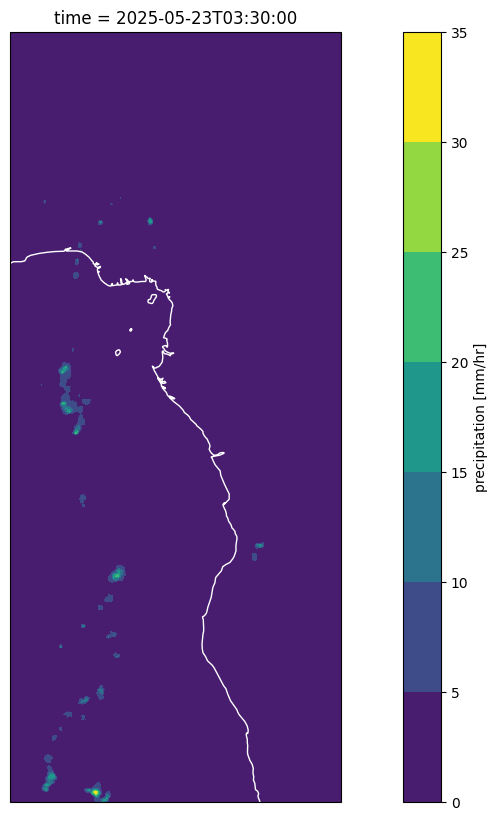

In [28]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
ew4_imerg_accessor['2025-05-23 03:30']['precipitation'][0].plot.contourf(ax=ax1)

ax1.coastlines(color='w')


In [29]:
ghana_extents = {
    'latitude': (4.5,11.25),
    'longitude': (-3.5, 1.5),
}


In [30]:
ghana_pet_box = (ghana_extents['latitude'][0],
                 ghana_extents['longitude'][0],
                 ghana_extents['latitude'][1],
                 ghana_extents['longitude'][1],
                )

In [31]:
help(petpipe.modifications.TemporalWindow)

Help on class TemporalWindow in module pyearthtools.pipeline.modifications.idx_modification:

class TemporalWindow(pyearthtools.pipeline.controller.PipelineIndex)
 |  TemporalWindow(*, prior_indexes, posterior_indexes, timedelta, merge_method=None)
 |
 |  The purpose of this class is to provide the ability to perform
 |  sequence-to-sequence modelling from a data accessor or pipeline
 |  that was designed to produce single time steps (i.e. single samples).
 |
 |  The temporal window allows the specification of the 'back window'
 |  and the 'forward window', and will produce a binary branch.
 |
 |  For example, if the time steps are hourly, and the base pipeline
 |  can produce hours 1, 2, 3 ... 10; then this Temporal Window can
 |  be used to produce sequence pairs like::
 |
 |       [1,2,3], [4],
 |       [2,3,4], [5],
 |       ...
 |       [7,8,9], [10]
 |
 |  or like::
 |
 |       [1,2], [3,4,5],
 |       [2,3], [4,5,6],
 |       ...
 |       [6,7], [8,9,10]
 |
 |  This provides a s

In [68]:
ew4_imerg_pipeline = petpipe.Pipeline(
    ew4_imerg_accessor,
    petdata.transform.region.Bounding(*ghana_pet_box),  
    petpipe.modifications.TemporalWindow(prior_indexes=[0,], posterior_indexes=[0,], timedelta=TimeDelta('30 minutes')),
    iterator=petpipe.iterators.DateRange('20250501T00', '20250511T00', interval='30 minutes').randomise(), 
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)


Calculated indexes


In [69]:
ds_list = [sample1[0][0] for sample1 in ew4_imerg_pipeline]

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


2025-05-02T04
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250502-S040000-E042959.0240.V07B.HDF5.SUB.nc4')]


/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_f

2025-05-02T04
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250502-S040000-E042959.0240.V07B.HDF5.SUB.nc4')]
2025-05-06T21
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250506-S210000-E212959.1260.V07B.HDF5.SUB.nc4')]
2025-05-06T21
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250506-S210000-E212959.1260.V07B.HDF5.SUB.nc4')]
2025-05-01T10
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S100000-E102959.0600.V07B.HDF5.SUB.nc4')]
2025-05-01T10
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S100000-E102959.0600.V07B.HDF5.SUB.nc4')]
2025-05-02T22
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250502-S223000-E225959.1350.V07B.HDF5.SUB.nc4')]
2025-05-02T22
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250502-S223000-E225959.1350.V07B.HDF5.SUB.nc4')]
2025-0

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_f

...

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_f

2025-05-02T05
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250502-S050000-E052959.0300.V07B.HDF5.SUB.nc4')]
2025-05-09T06
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250509-S063000-E065959.0390.V07B.HDF5.SUB.nc4')]
2025-05-09T06
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250509-S063000-E065959.0390.V07B.HDF5.SUB.nc4')]
2025-05-02T03
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250502-S030000-E032959.0180.V07B.HDF5.SUB.nc4')]
2025-05-02T03
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250502-S030000-E032959.0180.V07B.HDF5.SUB.nc4')]
2025-05-09T12
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250509-S123000-E125959.0750.V07B.HDF5.SUB.nc4')]
2025-05-09T12
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250509-S123000-E125959.0750.V07B.HDF5.SUB.nc4')]
2025-0

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_f

2025-05-02T17
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250502-S170000-E172959.1020.V07B.HDF5.SUB.nc4')]
2025-05-02T17
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250502-S170000-E172959.1020.V07B.HDF5.SUB.nc4')]
2025-05-07T03
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250507-S030000-E032959.0180.V07B.HDF5.SUB.nc4')]
2025-05-07T03
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250507-S030000-E032959.0180.V07B.HDF5.SUB.nc4')]
2025-05-09T04
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250509-S040000-E042959.0240.V07B.HDF5.SUB.nc4')]
2025-05-09T04
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250509-S040000-E042959.0240.V07B.HDF5.SUB.nc4')]
2025-05-10T16
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250510-S160000-E162959.0960.V07B.HDF5.SUB.nc4')]
2025-0

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_f

In [61]:
ds_list[12]

<xarray.Dataset> Size: 18kB
Dimensions:        (time: 1, longitude: 98, latitude: 45)
Coordinates:
  * time           (time) datetime64[ns] 8B 2025-05-01T06:00:00
  * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
  * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
Data variables:
    precipitation  (time, longitude, latitude) float32 18kB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250501-S...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [34]:
ew4_imerg_pipeline['20250503T0700']

2025-05-03T07
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250503-S070000-E072959.0420.V07B.HDF5.SUB.nc4')]
2025-05-03T07
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250503-S070000-E072959.0420.V07B.HDF5.SUB.nc4')]


/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


([<xarray.Dataset> Size: 18kB
  Dimensions:        (time: 1, longitude: 98, latitude: 45)
  Coordinates:
    * time           (time) datetime64[ns] 8B 2025-05-03T07:00:00
    * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
    * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
  Data variables:
      precipitation  (time, longitude, latitude) float32 18kB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
  Attributes:
      CDI:                                    Climate Data Interface version 1....
      Conventions:                            CF-1.6
      Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
      Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
      Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
      InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250503-S...
      history_L34RS:                          'Created

In [35]:
next(iter(ew4_imerg_pipeline))

2025-05-01T00
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S000000-E002959.0000.V07B.HDF5.SUB.nc4')]
2025-05-01T00
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S000000-E002959.0000.V07B.HDF5.SUB.nc4')]


([<xarray.Dataset> Size: 18kB
  Dimensions:        (time: 1, longitude: 98, latitude: 45)
  Coordinates:
    * time           (time) datetime64[ns] 8B 2025-05-01
    * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
    * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
  Data variables:
      precipitation  (time, longitude, latitude) float32 18kB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
  Attributes:
      CDI:                                    Climate Data Interface version 1....
      Conventions:                            CF-1.6
      Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
      Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
      Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
      InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250501-S...
      history_L34RS:                          'Created by L34RS

2025-05-01T16
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S160000-E162959.0960.V07B.HDF5.SUB.nc4')]
2025-05-01T16
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S160000-E162959.0960.V07B.HDF5.SUB.nc4')]


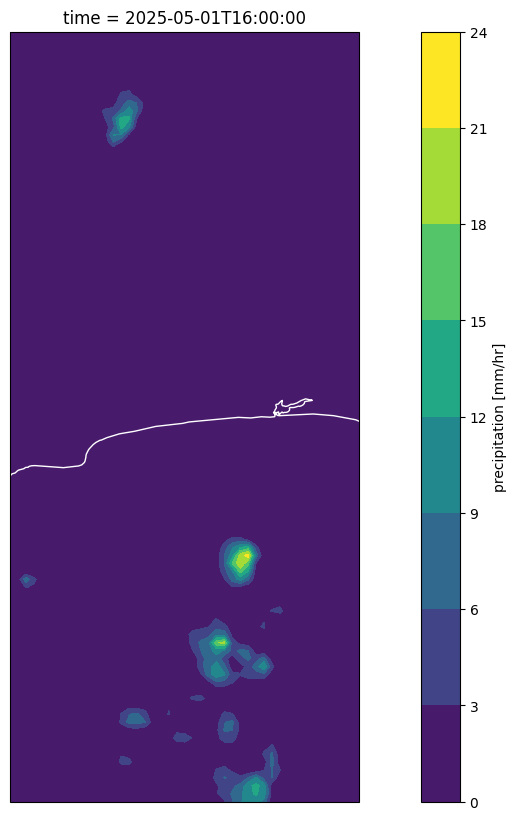

In [94]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
next(ew4_imerg_iter)[0][0]['precipitation'][0].plot.contourf(ax=ax1)
ax1.coastlines(color='w')


In [39]:
next(ew4_imerg_iter), next(ew4_imerg_iter),

2025-05-01T08
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S080000-E082959.0480.V07B.HDF5.SUB.nc4')]
2025-05-01T08
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S080000-E082959.0480.V07B.HDF5.SUB.nc4')]
2025-05-01T12
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S120000-E122959.0720.V07B.HDF5.SUB.nc4')]
2025-05-01T12
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S120000-E122959.0720.V07B.HDF5.SUB.nc4')]


(([<xarray.Dataset> Size: 18kB
   Dimensions:        (time: 1, longitude: 98, latitude: 45)
   Coordinates:
     * time           (time) datetime64[ns] 8B 2025-05-01T08:00:00
     * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
     * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
   Data variables:
       precipitation  (time, longitude, latitude) float32 18kB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
   Attributes:
       CDI:                                    Climate Data Interface version 1....
       Conventions:                            CF-1.6
       Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
       Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
       Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
       InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250501-S...
       history_L34RS:                  

In [40]:
#todo
# - find start and end time for data and select 1 day
# get all files
# load into dataset
# create a PET accessor to load those files
# demonstrate visualising
# create a demo autoencoder for the data


## Train an ML model
To demonsyrate how we can use this data in a machine learning training pipeline, we will show a simple autoencoder

In [127]:
ew4_imerge_train_pipe = petpipe.Pipeline(
    ew4_imerg_accessor,
    petdata.transform.region.Bounding(*ghana_pet_box),  
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    petpipe.modifications.TemporalWindow(prior_indexes=[0,], posterior_indexes=[0,], timedelta=TimeDelta('30 minutes')),
    iterator=petpipe.iterators.DateRange('20250501T00', '20250701T00', interval='30 minutes').randomise(), 
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)

Calculated indexes


In [128]:
test_it = iter(ew4_imerge_train_pipe)

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_f

2025-05-12T13
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250512-S133000-E135959.0810.V07B.HDF5.SUB.nc4')]
2025-05-12T13
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250512-S133000-E135959.0810.V07B.HDF5.SUB.nc4')]
2025-05-17T06
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250517-S060000-E062959.0360.V07B.HDF5.SUB.nc4')]
2025-05-17T06
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250517-S060000-E062959.0360.V07B.HDF5.SUB.nc4')]
2025-06-19T17
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250619-S170000-E172959.1020.V07B.HDF5.SUB.nc4')]
2025-06-19T17
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250619-S170000-E172959.1020.V07B.HDF5.SUB.nc4')]
2025-05-15T00
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250515-S000000-E002959.0000.V07B.HDF5.SUB.nc4')]
2025-0

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


array([[[[0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]]],


       [[[0.        , 0.        , 0.        , ..., 6.7999997 ,
          6.5699997 , 6.7799997 ],
         [0.        , 0.        , 0.        , ..., 6.14      ,
          4.3399997 , 4.39      ],
         [0.        , 0.        , 0.        , ..., 4.7799997 ,
          3.73      , 4.4       ],
         ...,
         [0.19      , 4.35      , 0.61      , ..., 0.        ,
          0.        , 0

In [92]:
ew4_imerge_val_pipe = petpipe.Pipeline(
    ew4_imerg_accessor,
    petdata.transform.region.Bounding(*ghana_pet_box),  
    petpipe.modifications.TemporalWindow(prior_indexes=[0,], posterior_indexes=[0,], timedelta=TimeDelta('30 minutes')),
    petpipe.operations.xarray.conversion.ToNumpy(),
    iterator=petpipe.iterators.DateRange('20250701T00', '20250801T00', interval='30 minutes'), 
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)

In [42]:
# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [43]:
class ImergAutoEncoder(torch.nn.Module):
    def __init__(self, num_channels, max_pool=False):
        super(ImergAutoEncoder, self).__init__()

        # we have "hard coded" a lot of the architecture hyperparameters in our model class. 
        # Usually you want want to make these arguments for the class so you can vary hyperparameters more easily.
        # Hard coding here makes it easier to follow the architecture definition in the tutorial
        self.num_channels = num_channels
        
        self._latent_array_dims = (-1,32,8,16)
        self._prelatent_size = functools.reduce(lambda a,b:a*b, self._latent_array_dims[1:])
        self._latent_size = 500
        
        self._encoder = self._get_encoder(max_pool)
        self._decoder = self._get_decoder()

    def _get_encoder(self, max_pool):
        if max_pool:
            encoder = torch.nn.Sequential(
                torch.nn.Conv2d(in_channels=self.num_channels, 
                                out_channels=16, 
                                kernel_size=3, 
                                padding=1,
                               ),
                torch.nn.ReLU(),
                torch.nn.MaxPool2d(2, stride=2),
                torch.nn.Conv2d(in_channels=16, 
                                out_channels=32, 
                                kernel_size=3, 
                                padding=1,
                               ),
                torch.nn.ReLU(),
                torch.nn.MaxPool2d(2, stride=2),
                torch.nn.Flatten(1,-1)
            )
        else:
            encoder = torch.nn.Sequential(
                torch.nn.Conv2d(in_channels=self.num_channels, 
                                out_channels=16, 
                                kernel_size=3, 
                                padding=1,
                                stride=2,
                               ),
                torch.nn.ReLU(),
                torch.nn.Conv2d(in_channels=16, 
                                out_channels=32, 
                                kernel_size=3, 
                                padding=1,
                                stride=2,
                               ),
                torch.nn.ReLU(),
                torch.nn.Flatten(1, -1),
                # torch.nn.Linear(self._prelatent_size, self._latent_size),
                # torch.nn.ReLU(),
            )
        return encoder

    def _get_decoder(self):
        """
        """
        decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=2,stride=2),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=16, out_channels=self.num_channels, kernel_size=2,stride=2),
            # torch.nn.ReLU(),
            # torch.nn.Sigmoid(),   
        )
        return decoder
    def forward(self, x):

        # Get latent representation
        latent = self._encoder(x)

        # Reconstruct input
        reconstructed = self._decoder(latent.view(self._latent_array_dims))
        # reconstructed = self._decoder(latent)

        return reconstructed

In [46]:
# Initialize model and move to device
# ae_model = Era5AutoEncoder(wb_train_ds.num_channels, True).to(device)
ae_model = Era5AutoEncoder(1, False).to(device)

In [47]:
# Loss function and optimizer
loss_function = torch.nn.L1Loss()
# criterion = nn.KLDivLoss()
# loss_function = torch.nn.MSELoss()

optimizer = torch.optim.Adam(ae_model.parameters(), 
                             lr=5e-3)

In [48]:
num_epochs = 10

In [80]:
num_samples = len(ew4_imerge_train_pipe)
batch_size=8
num_batches = math.ceil(num_samples / batch_size)
num_batches

366

In [95]:
imerg_train_iter = iter(ew4_imerge_train_pipe)

In [96]:
batch_samples = []
for ix in range(batch_size):
    batch_samples  += [next(imerg_train_iter)]


/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_f

2025-06-16T17
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250616-S173000-E175959.1050.V07B.HDF5.SUB.nc4')]
2025-06-16T17
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250616-S173000-E175959.1050.V07B.HDF5.SUB.nc4')]
2025-05-06T15
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250506-S153000-E155959.0930.V07B.HDF5.SUB.nc4')]
2025-05-06T15
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250506-S153000-E155959.0930.V07B.HDF5.SUB.nc4')]
2025-06-19T08
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250619-S080000-E082959.0480.V07B.HDF5.SUB.nc4')]
2025-06-19T08
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250619-S080000-E082959.0480.V07B.HDF5.SUB.nc4')]
2025-06-14T08
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250614-S080000-E082959.0480.V07B.HDF5.SUB.nc4')]
2025-0

In [99]:
batch_samples[0]

(None, None)

In [76]:
367*8,num_samples

(2936, 2928)

In [ ]:
%%time
for epoch_num in range(num_epochs):
    print(epoch_num)
    epoch_train_loss = 0.0
    epoch_val_loss = 0.0
    
    for batch_ix in range(num_batches):
        predictor_batch_list = []
        target_batch_list = []
        for _ in range(batch_size):
            pred_sample, target_sample = next(test_it)
            predictor_batch_list += [pred_sample[0]]
            target_batch_list += [target_sample[0]]
        # create numpy array of a batch 
        predictor_array = numpy.concat(predictor_batch_list, axis=0)
        target_array = numpy.concat(target_batch_list, axis=0)
        
        # convert to a tensor and send to gpu
        predictor_gpu_tensor = torch.tensor(
            predictor_array,
            dtype=torch.float32,
        ).to(device)
        target_gpu_tensor = torch.tensor(
            target_array,
            dtype=torch.float32,
        ).to(device)        
        

        if (batch_ix % 100) == 0:
            print(batch_ix)

        # do training for batch
        optimizer.zero_grad()
        predictions = ae_model.forward(input_gpu_tensor_torch)
        loss_batch = loss_function(predictions, target_gpu_tensor)
        loss_batch.backward()
        optimizer.step()
        epoch_train_loss += loss_batch.to('cpu').item()
    epoch_train_loss /= len(wb_train_loader)

    #todo create a function to do the xarray to tensor in a single step, could this be a pipeline operation
    for batch_ix_val, X_batch_val in enumerate(wb_val_loader):
        predictions_val = ae_model.forward(X_batch_val.to(device))
        loss_batch_val = loss_function(predictions_val, X_batch_val.to(device))
        epoch_val_loss += loss_batch_val.to('cpu').item()
    epoch_val_loss /= len(wb_val_loader)
    
    print(epoch_train_loss)
    print(epoch_val_loss)
        
        
        
        
